In [1]:
# BLOCK 1 — SETUP

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler


In [2]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


DATASET_PATH = r"C:\Users\dell\ECG - Cardialyse Final Year Project\ECG_Dataset_Original" 

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [3]:
# CROPPING FUNCTION
import cv2

def crop_ecg_image(image):
    """
    Remove header and borders from ECG image.
    """
    
    h, w, _ = image.shape
    
    # Remove top header (approx 18%)
    top_crop = int(0.18 * h)
    bottom_crop = int(0.95 * h)
    
    # Remove small left/right margins
    left_crop = int(0.03 * w)
    right_crop = int(0.97 * w)
    
    cropped = image[top_crop:bottom_crop, left_crop:right_crop]
    
    return cropped

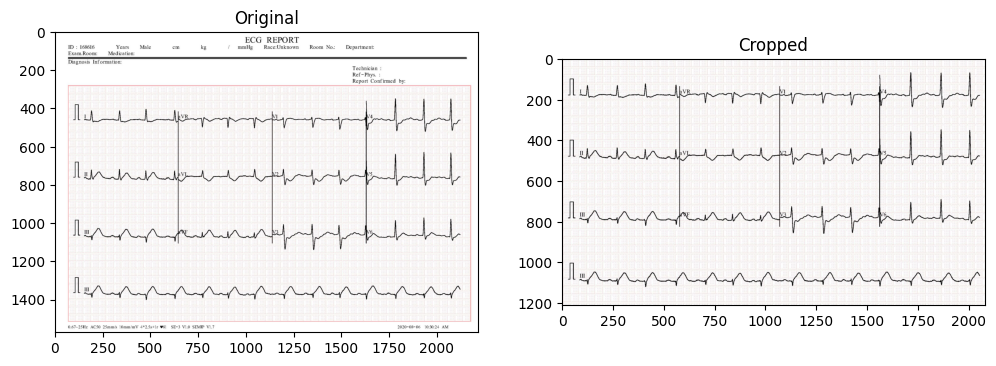

In [4]:
# Pick one sample image to visualize
sample_class = os.listdir(DATASET_PATH)[0]
sample_image_path = os.path.join(DATASET_PATH, sample_class,
                                 os.listdir(os.path.join(DATASET_PATH, sample_class))[0])

image = cv2.imread(sample_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

cropped_image = crop_ecg_image(image)

# Show comparison
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(cropped_image)
plt.title("Cropped")

plt.show()

In [5]:
# BLOCK 3 — PREPROCESSING FUNCTION
from tensorflow.keras.applications.vgg16 import preprocess_input
def preprocess_image(image_path):

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image = crop_ecg_image(image)

    image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    image = cv2.resize(image, (IMG_WIDTH, IMG_HEIGHT))
    image = np.stack([image, image, image], axis=-1)

    image = image.astype(np.float32)
    image = image / 255.0   # ONLY THIS

    return image

In [6]:
sample_class = sorted(os.listdir(DATASET_PATH))[0]
sample_image_name = os.listdir(os.path.join(DATASET_PATH, sample_class))[0]
sample_image_path = os.path.join(DATASET_PATH, sample_class, sample_image_name)

test_img = preprocess_image(sample_image_path)

print("Processed Shape:", test_img.shape)
print("Min value:", test_img.min())
print("Max value:", test_img.max())

Processed Shape: (224, 224, 3)
Min value: 0.0
Max value: 1.0


In [7]:
# BLOCK 4 — LOAD FULL DATASET

X = []
y = []

# Get sorted class names (important for consistency)
class_names = sorted(os.listdir(DATASET_PATH))
label_map = {class_name: idx for idx, class_name in enumerate(class_names)}

print("Class Mapping:")
print(label_map)

for class_name in class_names:
    class_folder = os.path.join(DATASET_PATH, class_name)
    
    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)
        
        try:
            processed_img = preprocess_image(img_path)
            X.append(processed_img)
            y.append(label_map[class_name])
        except Exception as e:
            print(f"Skipping {img_path} due to error:", e)

# Convert to numpy arrays
X = np.array(X, dtype=np.float32)
y = np.array(y)

print("\nDataset Loaded Successfully")
print("Total Samples:", X.shape[0])
print("Image Shape:", X.shape[1:])

Class Mapping:
{'ECG Images of Myocardial Infarction Patients (240x12=2880)': 0, 'ECG Images of Patient that have History of MI (172x12=2064)': 1, 'ECG Images of Patient that have abnormal heartbeat (233x12=2796)': 2, 'Normal Person ECG Images (284x12=3408)': 3}

Dataset Loaded Successfully
Total Samples: 928
Image Shape: (224, 224, 3)


In [8]:
# BLOCK 5 — STRATIFIED SPLIT

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

# Second split: 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

Train size: 649
Validation size: 139
Test size: 140


In [9]:
# BLOCK 6 — VGG16 FEATURE EXTRACTOR

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

# Load VGG16 backbone
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Freeze all layers
base_model.trainable = False

# Build feature extractor model
inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Apply ImageNet preprocessing
x = layers.Lambda(preprocess_input)(inputs)

# Pass through VGG
x = base_model(x, training=False)

# Global pooling to get 512 features
x = layers.GlobalAveragePooling2D()(x)

feature_extractor = keras.Model(inputs, x)

feature_extractor.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda (Lambda)                      │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
# BLOCK-7 EXTRACTING DEEP FEATURES

train_ds = tf.data.Dataset.from_tensor_slices(X_train).batch(BATCH_SIZE)
val_ds   = tf.data.Dataset.from_tensor_slices(X_val).batch(BATCH_SIZE)
test_ds  = tf.data.Dataset.from_tensor_slices(X_test).batch(BATCH_SIZE)

In [11]:
print("Extracting training features...")
X_train_features = feature_extractor.predict(train_ds)

print("Extracting validation features...")
X_val_features = feature_extractor.predict(val_ds)

print("Extracting test features...")
X_test_features = feature_extractor.predict(test_ds)

print("Train feature shape:", X_train_features.shape)
print("Validation feature shape:", X_val_features.shape)
print("Test feature shape:", X_test_features.shape)

Extracting training features...
21/21 ━━━━━━━━━━━━━━━━━━━━ 252s 12s/step
Extracting validation features...
5/5 ━━━━━━━━━━━━━━━━━━━━ 54s 10s/step
Extracting test features...
5/5 ━━━━━━━━━━━━━━━━━━━━ 54s 11s/step
Train feature shape: (649, 512)
Validation feature shape: (139, 512)
Test feature shape: (140, 512)


In [12]:
# SAVE EXTRACTED FEATURES

np.savez_compressed(
    "ecg_vgg16_features.npz",
    X_train_features=X_train_features,
    X_val_features=X_val_features,
    X_test_features=X_test_features,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test
)

print("Features saved successfully.")

Features saved successfully.


In [13]:
print("Train feature shape:", X_train_features.shape)

# Print first feature vector
print("\nFirst feature vector (first 20 values):")
print(X_train_features[0][:20])

Train feature shape: (649, 512)

First feature vector (first 20 values):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


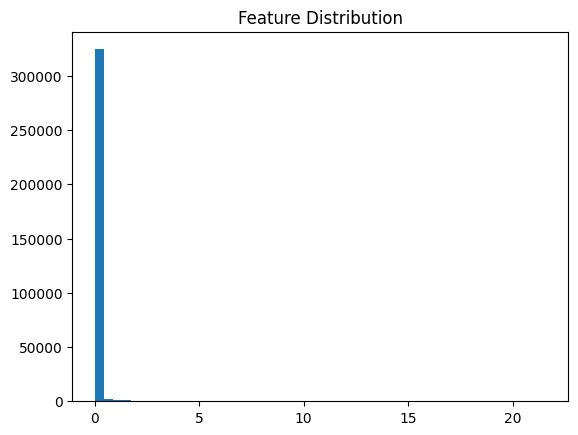

In [14]:
plt.hist(X_train_features.flatten(), bins=50)
plt.title("Feature Distribution")
plt.show()

In [15]:
import pandas as pd

df_features = pd.DataFrame(X_train_features)
df_features.head()

,0,1,2,3,4,5,6,7,8,9,...,502,503,504,505,506,507,508,509,510,511
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.723066,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.090615,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.728446,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.095470,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.758736,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.097792,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.811975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.103086,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.704091,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.098606,0.0


In [16]:
import numpy as np
print("Train label distribution:", np.bincount(y_train))
print("Validation label distribution:", np.bincount(y_val))
print("Test label distribution:", np.bincount(y_test))

Train label distribution: [167 120 163 199]
Validation label distribution: [36 26 35 42]
Test label distribution: [36 26 35 43]


In [17]:
# BLOCK-8 TRAINING & EVALUATING SVM

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_features)
X_val_scaled   = scaler.transform(X_val_features)
X_test_scaled  = scaler.transform(X_test_features)

In [18]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    probability = True
)

print("Training SVM...")
svm_model.fit(X_train_scaled, y_train)

Training SVM...


SVC(C=10, class_weight='balanced', probability=True)

In [19]:
from sklearn.metrics import accuracy_score, classification_report

val_preds = svm_model.predict(X_val_scaled)

print("Validation Accuracy:", accuracy_score(y_val, val_preds))
print("\nValidation Classification Report:")
print(classification_report(y_val, val_preds))

Validation Accuracy: 0.8776978417266187

Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.79      0.73      0.76        26
           2       0.90      0.74      0.81        35
           3       0.82      0.98      0.89        42

    accuracy                           0.88       139
   macro avg       0.88      0.86      0.87       139
weighted avg       0.88      0.88      0.88       139



In [20]:
test_preds = svm_model.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, test_preds))
print("\nTest Classification Report:")
print(classification_report(y_test, test_preds))

Test Accuracy: 0.8785714285714286

Test Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        36
           1       0.81      0.85      0.83        26
           2       0.83      0.83      0.83        35
           3       0.90      0.84      0.87        43

    accuracy                           0.88       140
   macro avg       0.87      0.88      0.87       140
weighted avg       0.88      0.88      0.88       140



In [21]:
# BLOCK - 9 SAVING THE MODEL

import joblib
import json

clean_label_mapping = {
    0: "Myocardial Infarction",
    1: "History of Myocardial Infarction",
    2: "Abnormal Heartbeat - Arrhythmias",
    3: "Normal ECG"
}

# Save SVM
joblib.dump(svm_model, "ecg_svm_model.pkl")

# Save scaler
joblib.dump(scaler, "ecg_scaler.pkl")

# Save label mapping
with open("class_mapping.json", "w") as f:
    json.dump(clean_label_mapping, f)

print("System saved successfully.")

System saved successfully.


In [22]:
# BLOCK-10 CURVES
from sklearn.preprocessing import label_binarize

# Get probabilities
y_test_proba = svm_model.predict_proba(X_test_scaled)

# Binarize labels for ROC
y_test_bin = label_binarize(y_test, classes=[0,1,2,3])

n_classes = y_test_bin.shape[1]

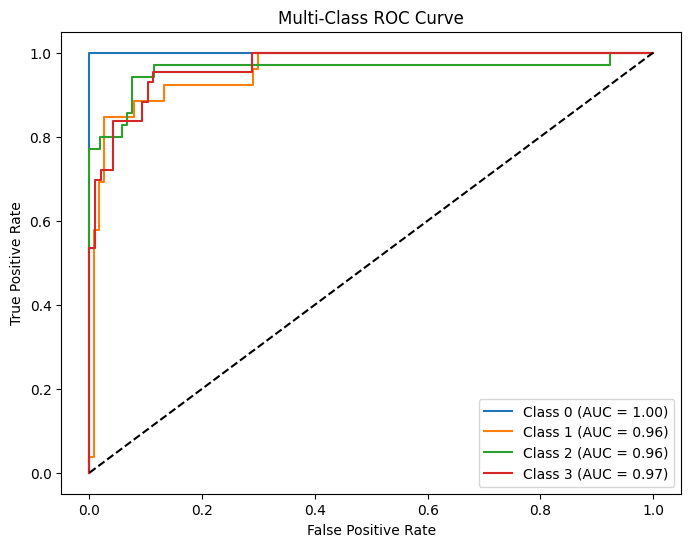

In [23]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()

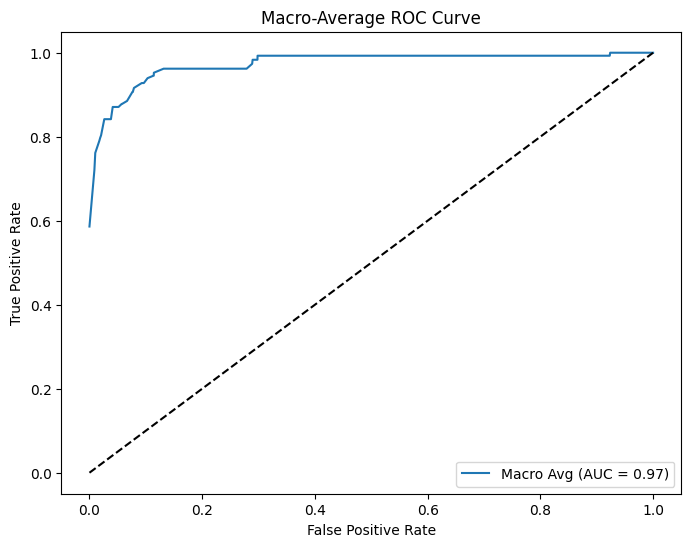

In [24]:
from numpy import interp

# Compute macro-average ROC curve
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes
macro_auc = auc(all_fpr, mean_tpr)

plt.figure(figsize=(8,6))
plt.plot(all_fpr, mean_tpr, label=f"Macro Avg (AUC = {macro_auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro-Average ROC Curve")
plt.legend()
plt.show()

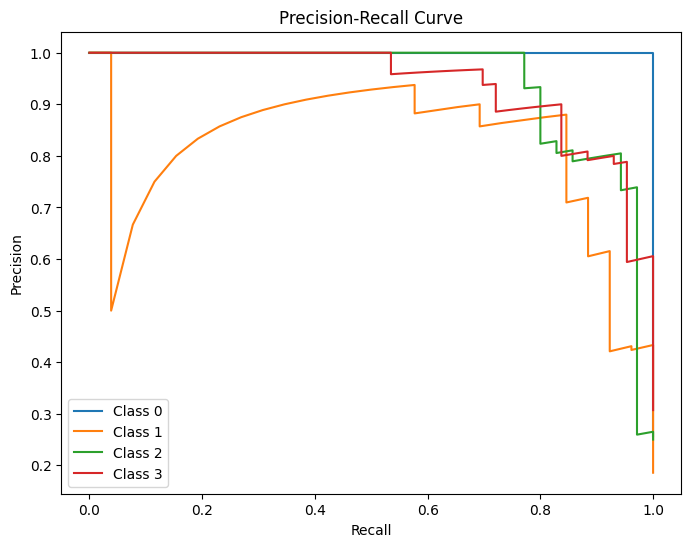

In [26]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_test_proba[:, i])
    plt.plot(recall, precision, label=f"Class {i}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

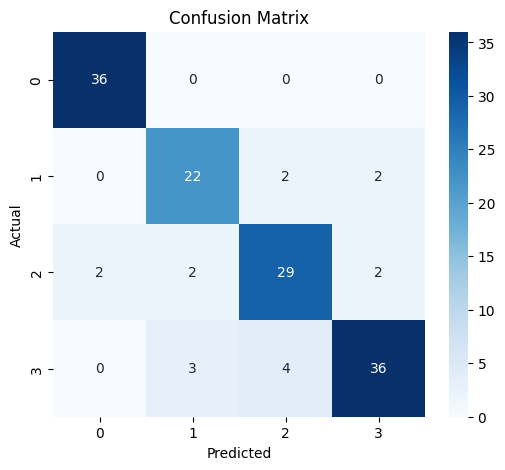

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, svm_model.predict(X_test_scaled))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()